# Dataset Exploration and Visualization

## Imports and Model Processors

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

In [3]:
from dataset.dataloader import get_dataset, get_dataloaders
from dataset.transforms import get_train_transform, get_age_transform, get_val_transform

/home/ashkanrn/01-Project/University/Deep-Learning/DL-project/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from model.clip   import processor as clip_processor
from model.dinov2 import processor as dinov2_processor
from model.siglip import processor as siglip_processor

## Helper Functions

In [6]:
age_names = ["0: 0-2","1: 3-9","2: 10-19","3: 20-29",
             "4: 30-39","5: 40-49","6: 50-59",
             "7: 60-69","8: more than 70"]
gender_names = ["0: Male","1: Female"]
race_names = ["0: East Asian","1: Indian","2: Black",
              "3: White","4: Middle Eastern",
              "5: Latino_Hispanic","6: Southeast Asian"]

import math



# # Visualize raw images without any processor or transform.
def show_samples(dataset, dataframe, n=8, cols=4):

    samples = dataframe.sample(n)
    
    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols * 2.5, rows * 2.5))
    
    for i, (sample_idx, s) in enumerate(samples.iterrows()):
        img = dataset[sample_idx][0]
        
        plt.subplot(rows, cols, i+1)  # rows, cols
        plt.imshow(img)
        
        plt.axis("off")
        plt.title(f"{sample_idx}, {race_names[s['race']]}, {age_names[s['age']]}", fontsize=8)
    
    plt.tight_layout()
    plt.show()



def explore_dataset(df, name="Dataset"):

    print(f"{"="*15}",name,f"{"="*15}\n")
    print(df.describe(include="all"))


    print("\nImbalance ratios:")

    for col in ["age", "gender", "race"]:
        counts = df[col].value_counts()
        print(f"{col}: max/min ratio = {counts.max()/counts.min():.2f}")


    ## Gender

    counts = df['gender'].value_counts().sort_index()
    ax = counts.plot(
        kind='bar',
        figsize=(3,5),
        title=f'{name} - Gender Distribution'
    )

    ax.set_xticklabels(
        gender_names,
        rotation=45,
        ha='right'
    )

    ax.bar_label(ax.containers[0])
    plt.show()



    ## Age

    counts = df['age'].value_counts().sort_index()
    ax = counts.plot(
        kind='bar',
        figsize=(10,5),
        title=f'{name} - Age Distribution'
    )

    ax.set_xticklabels(
        age_names,
        rotation=45,
        ha='right'
    )

    ax.bar_label(ax.containers[0])
    plt.show()


    ## Race

    counts = df['race'].value_counts().sort_index()
    ax = counts.plot(
        kind='bar',
        figsize=(9,5),
        title=f'{name} - Race Distribution'
    )

    ax.set_xticklabels(
        race_names,
        rotation=45,
        ha='right'
    )

    ax.bar_label(ax.containers[0])
    plt.show()




    

## Dataset Loading

In [7]:
train_set, val_set = get_dataset()
train_dataloader, val_dataloader = get_dataloaders(train_set, val_set)

In [8]:
train_df = pd.DataFrame({
    "age": train_set.dataset["age"],
    "gender": train_set.dataset["gender"],
    "race": train_set.dataset["race"],
})


val_df = pd.DataFrame({
    "age": val_set.dataset["age"],
    "gender": val_set.dataset["gender"],
    "race": val_set.dataset["race"],
})

## Visualization

### Training Set

=============== Training Set ===============

                age        gender          race
count  86744.000000  86744.000000  86744.000000
mean       3.454821      0.469865      2.937782
std        1.637914      0.499094      1.955181
min        0.000000      0.000000      0.000000
25%        3.000000      0.000000      1.000000
50%        3.000000      0.000000      3.000000
75%        4.000000      1.000000      5.000000
max        8.000000      1.000000      6.000000

Imbalance ratios:
age: max/min ratio = 30.40
gender: max/min ratio = 1.13
race: max/min ratio = 1.79


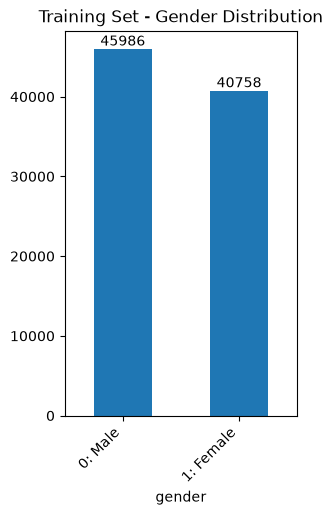

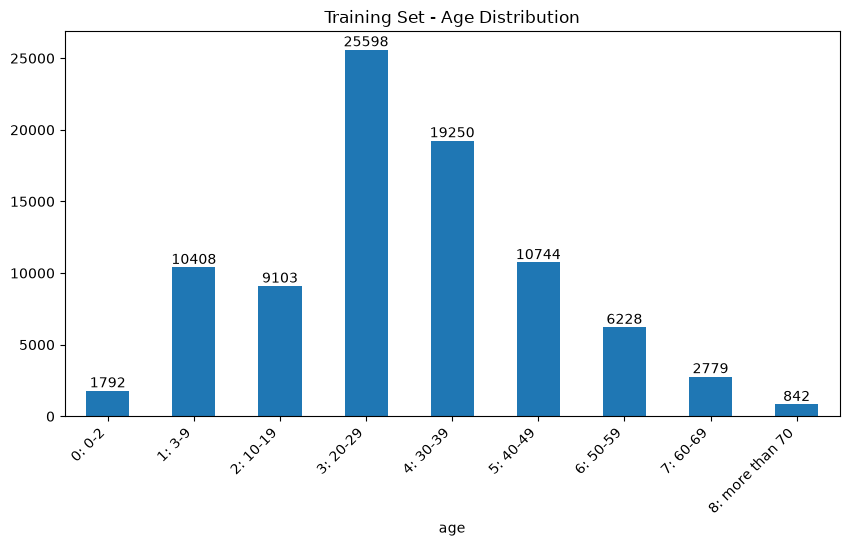

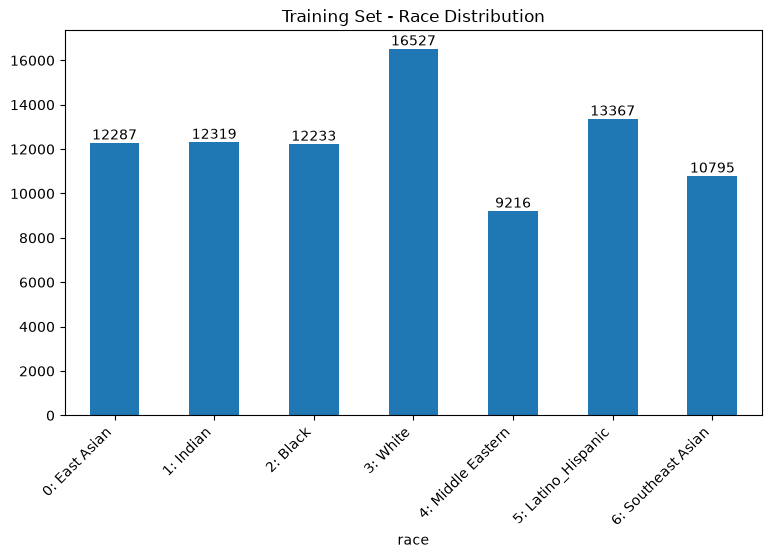

age 29.509822004980172 30.401425178147267
gender 53.01346490823573 1.128269296825163
race 19.052614590058102 1.7932942708333333


In [9]:
explore_dataset(train_df, "Training Set")
for col in ["age", "gender", "race"]:
    counts = train_df[col].value_counts()
    majority_percentage = counts.max() / counts.sum() * 100
    imbalance = counts.max() / counts.min()

    print(col, majority_percentage, imbalance)

### Validation Set

=============== Validation Set ===============

                age        gender          race
count  10954.000000  10954.000000  10954.000000
mean       3.438926      0.471243      2.950886
std        1.634939      0.499195      1.957729
min        0.000000      0.000000      0.000000
25%        3.000000      0.000000      1.000000
50%        3.000000      0.000000      3.000000
75%        4.000000      1.000000      5.000000
max        8.000000      1.000000      6.000000

Imbalance ratios:
age: max/min ratio = 27.97
gender: max/min ratio = 1.12
race: max/min ratio = 1.72


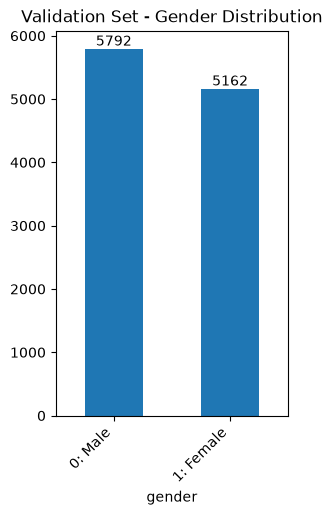

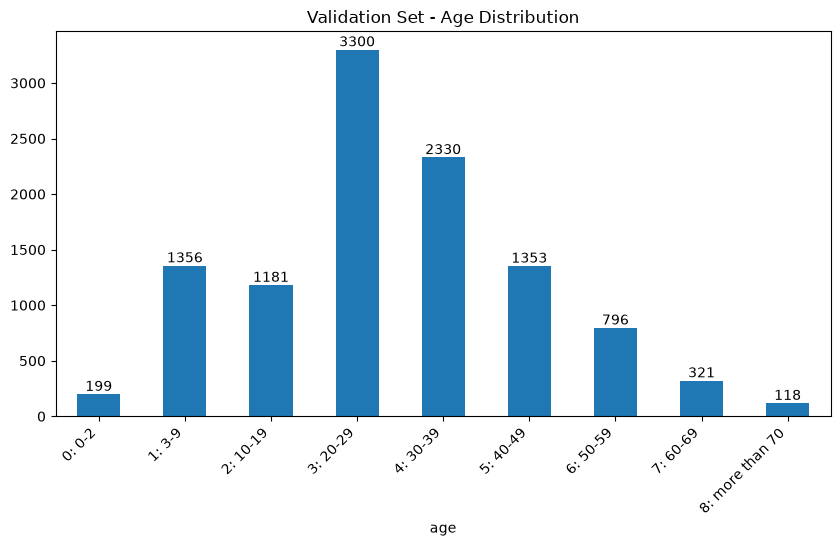

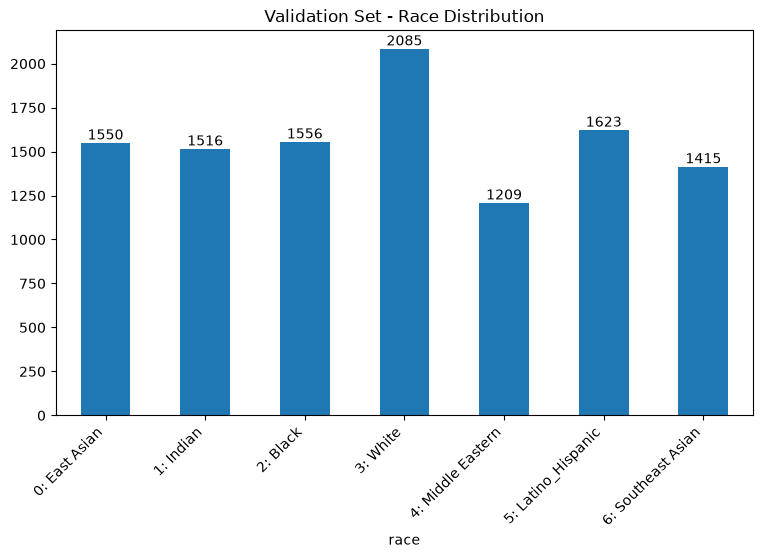

In [ ]:
explore_dataset(val_df, "Validation Set")

## Random Sample Visualization

### Training Samples

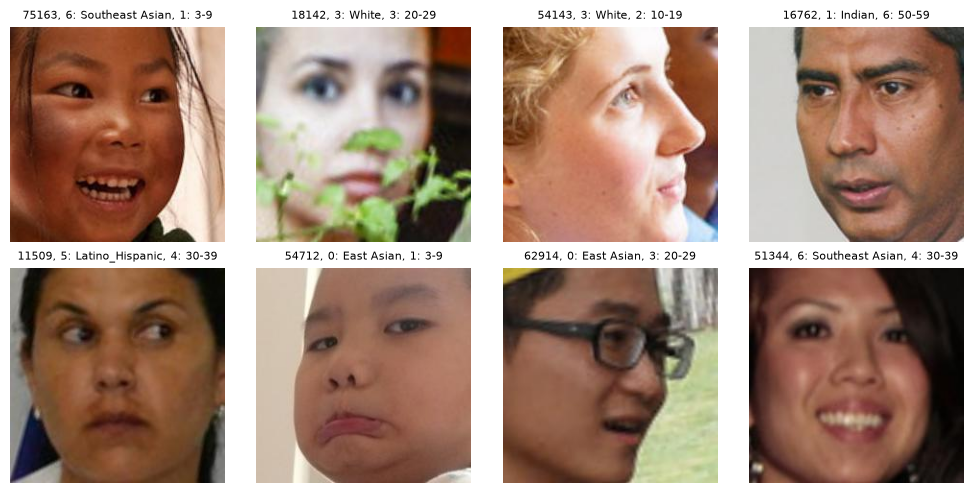

In [16]:

show_samples(train_set, train_df, n=8)

### Validation Samples

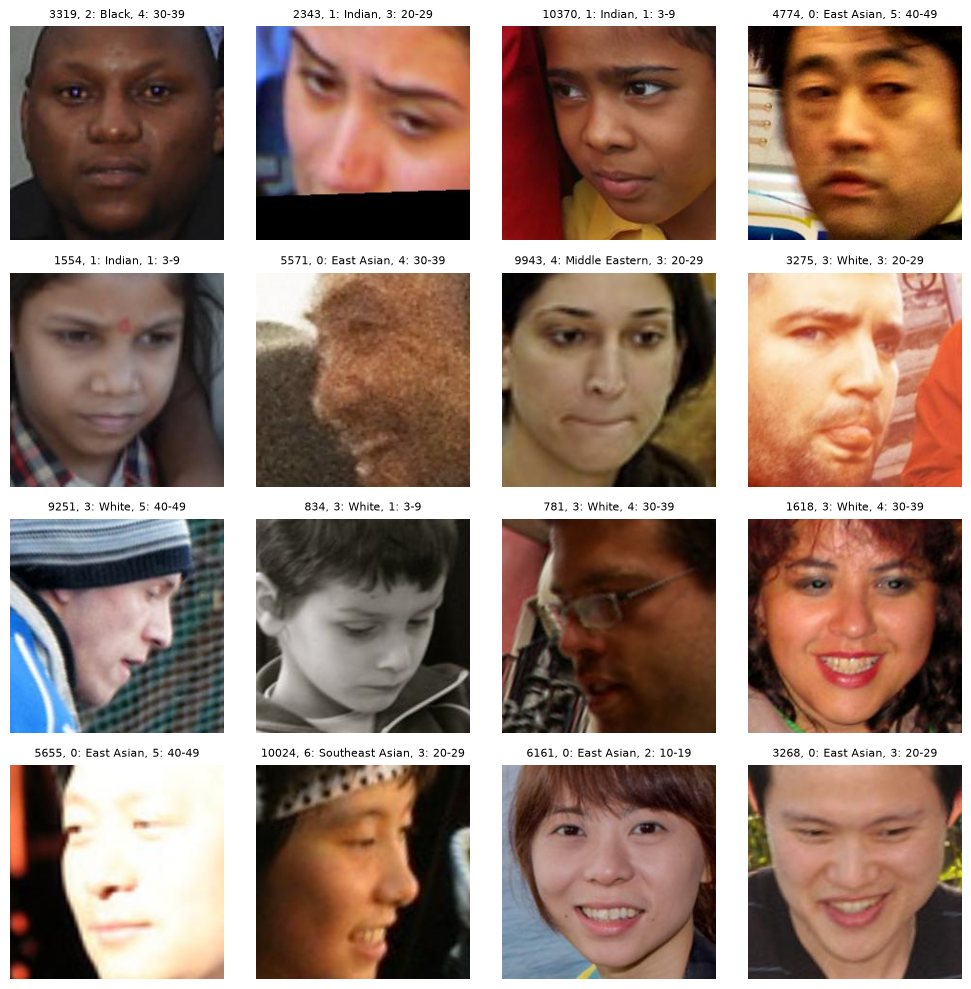

In [ ]:
show_samples(val_set, val_df, n=16)

## DataLoader Verification

In [ ]:
# Apply required transforms because the dataloader expects tensor inputs.
# Here, CLIP processor is used for image preprocessing.

transformed_train_set, transformed_val_set = get_dataset(    
    get_train_transform(clip_processor.image_processor), 
    get_age_transform(clip_processor.image_processor), 
    get_val_transform(clip_processor.image_processor)
)
transformed_train_dataloader, transformed_val_dataloader = get_dataloaders(transformed_train_set, transformed_val_set)

In [ ]:
print(len(transformed_train_dataloader))
X, Y = next(iter(transformed_train_dataloader))
# images and lables blongs to 32 samples (1 batch) 

2711


In [ ]:
print(X.shape)

for k, v in Y.items():
    print(k, v.shape, v.dtype)

torch.Size([32, 3, 224, 224])
gender torch.Size([32]) torch.int64
age torch.Size([32]) torch.int64
race torch.Size([32]) torch.int64


## Class Distribution Analysis

In [ ]:
print(np.unique(train_df['gender']))
print(np.unique(train_df['race']))
print(np.unique(train_df['age']))


[0 1]
[0 1 2 3 4 5 6]
[0 1 2 3 4 5 6 7 8]


In [ ]:
age_class_0 = train_df[train_df['age'] == 0]
age_class_7 = train_df[train_df['age'] == 7]
age_class_8 = train_df[train_df['age'] == 8]

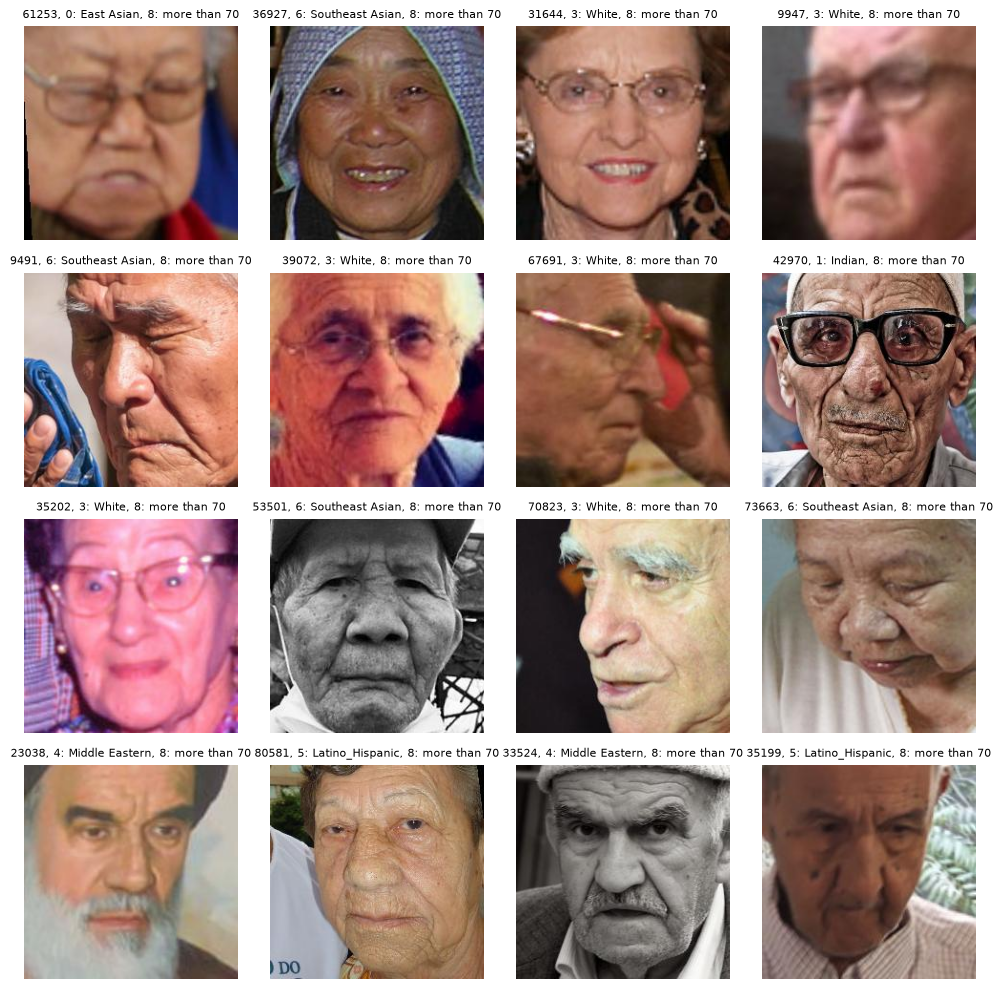

In [ ]:
show_samples(train_set, age_class_8, n=16)